In [1]:
import torch
import random
import numpy as np

# --------------------------------------------------
# Reproducibility Seed
# --------------------------------------------------

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed set for reproducibility.")

Random seed set for reproducibility.


# *Loading Data*

In [2]:
train = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train"
test = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test"
validation = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation"

In [3]:
import os

def load_images_from_dirs(dir_list):
    all_images = []

    for directory in dir_list:
        for img in os.listdir(directory):
            img_path = os.path.join(directory, img)

            if os.path.isfile(img_path):
                all_images.append(img_path)

    return all_images

In [4]:
test_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/NeuralTextures"
]

test_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/real"
]

test_fake = load_images_from_dirs(test_fake_dirs)
test_real = load_images_from_dirs(test_real_dirs)

print(len(test_fake))
print(len(test_real))

2250
2250


In [5]:
train_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/NeuralTextures"
]

train_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/real"
]

train_fake = load_images_from_dirs(train_fake_dirs)
train_real = load_images_from_dirs(train_real_dirs)

print(len(train_fake))
print(len(train_real))

10500
10500


In [6]:
validation_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/NeuralTextures"
]

validation_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/real"
]

validation_fake = load_images_from_dirs(validation_fake_dirs)
validation_real = load_images_from_dirs(validation_real_dirs)

print(len(validation_fake))
print(len(validation_real))

2250
2250


# Data loaders 


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import time
import copy

class DeepfakeDataset(Dataset):
    def __init__(self, fake_paths, real_paths, transform=None):
        
        self.image_paths = fake_paths + real_paths
        self.labels = [1] * len(fake_paths) + [0] * len(real_paths)
        
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
IMG_SIZE = 299

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = DeepfakeDataset(
    train_fake,
    train_real,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    validation_fake,
    validation_real,
    transform=val_test_transform
)

test_dataset = DeepfakeDataset(
    test_fake,
    test_real,
    transform=val_test_transform
)

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

21000
4500
4500
torch.Size([32, 3, 299, 299])
torch.Size([32])


# *Train Model Function*

In [12]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=25,
    patience=5,
    save_path="best_model.pth"
):

    since = time.time()

    # --------------------------------------------------------
    # AUTOMATIC DEVICE DETECTION
    # --------------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    # --------------------------------------------------------
    # BEST MODEL TRACKING
    # --------------------------------------------------------

    best_model_wts = copy.deepcopy(model.state_dict())

    best_acc = 0.0

    epochs_no_improve = 0

    early_stop = False

    # --------------------------------------------------------
    # HISTORY TRACKING
    # --------------------------------------------------------

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(num_epochs):

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # ====================================================
        # TRAIN + VALIDATION PHASES
        # ====================================================

        for phase in ['train', 'val']:

            if phase == 'train':

                model.train()

                dataloader = train_loader

            else:

                model.eval()

                dataloader = val_loader

            running_loss = 0.0

            running_corrects = 0

            # =================================================
            # ITERATE OVER DATA
            # =================================================

            for inputs, labels in dataloader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                # --------------------------------------------
                # ZERO GRADIENTS
                # --------------------------------------------

                optimizer.zero_grad()

                # --------------------------------------------
                # FORWARD PASS
                # --------------------------------------------

                with torch.set_grad_enabled(
                    phase == 'train'
                ):

                    outputs = model(inputs)

                    _, preds = torch.max(
                        outputs,
                        1
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    # ----------------------------------------
                    # BACKWARD + OPTIMIZE
                    # ----------------------------------------

                    if phase == 'train':

                        loss.backward()

                        optimizer.step()

                # --------------------------------------------
                # STATISTICS
                # --------------------------------------------

                running_loss += (
                    loss.item() * inputs.size(0)
                )

                running_corrects += torch.sum(
                    preds == labels.data
                )

            # =================================================
            # EPOCH METRICS
            # =================================================

            epoch_loss = (
                running_loss / len(dataloader.dataset)
            )

            epoch_acc = (
                running_corrects.double()
                / len(dataloader.dataset)
            )

            print(
                f'{phase} Loss: '
                f'{epoch_loss:.4f} '
                f'Acc: {epoch_acc:.4f}'
            )

            history[f'{phase}_loss'].append(
                epoch_loss
            )

            history[f'{phase}_acc'].append(
                epoch_acc.item()
            )

            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if phase == 'val':

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    epochs_no_improve = 0

                    # ----------------------------------------
                    # SAVE BEST MODEL
                    # ----------------------------------------

                    torch.save(
                        model.state_dict(),
                        save_path
                    )

                    print(
                        "Best model saved."
                    )

                else:

                    epochs_no_improve += 1

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if epochs_no_improve == patience:

            print(
                f'Early stopping triggered '
                f'after {patience} epochs '
                f'with no improvement '
                f'in validation accuracy.'
            )

            early_stop = True

            break

        # ====================================================
        # CLEAR CUDA CACHE
        # ====================================================

        torch.cuda.empty_cache()

    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    time_elapsed = time.time() - since

    print(
        f'Training complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f'Best val Acc: {best_acc:.4f}')

    # ========================================================
    # LOAD BEST MODEL WEIGHTS
    # ========================================================

    model.load_state_dict(best_model_wts)

    return model, history

print(
    "Training function `train_model` defined. "
    "You can now call it normally."
)

Training function `train_model` defined. You can now call it normally.


# Fusion Models 

Device: cuda:0

Rebuilding XceptionNet-41 architecture...
XceptionNet-41 loaded from best_xception41.pth

Rebuilding XceptionNet-65 architecture...
XceptionNet-65 loaded from best_xception65.pth

Fusion Model Summary
Total parameters  : 67,182,758
Trainable params  : 2,164,866  ← fusion head only
Frozen params     : 65,017,892  ← both backbones
Batch size    : 32  (matches both backbone training runs)
Input size    : 299x299
Train batches : 657
Val   batches : 141
Test  batches : 141
Epoch [01/30]  Train Loss: 0.0497  Acc: 0.9822  |  Val Loss: 0.5578  Acc: 0.9071  (743.6s)
  ✓ Best model saved
Epoch [02/30]  Train Loss: 0.0403  Acc: 0.9860  |  Val Loss: 0.3834  Acc: 0.9000  (759.2s)
  ✓ Best model saved
Epoch [03/30]  Train Loss: 0.0376  Acc: 0.9872  |  Val Loss: 0.3911  Acc: 0.9116  (760.2s)
Epoch [04/30]  Train Loss: 0.0366  Acc: 0.9867  |  Val Loss: 0.4537  Acc: 0.9069  (759.7s)
Epoch [05/30]  Train Loss: 0.0340  Acc: 0.9871  |  Val Loss: 0.4361  Acc: 0.9049  (760.0s)
Epoch [06/30] 

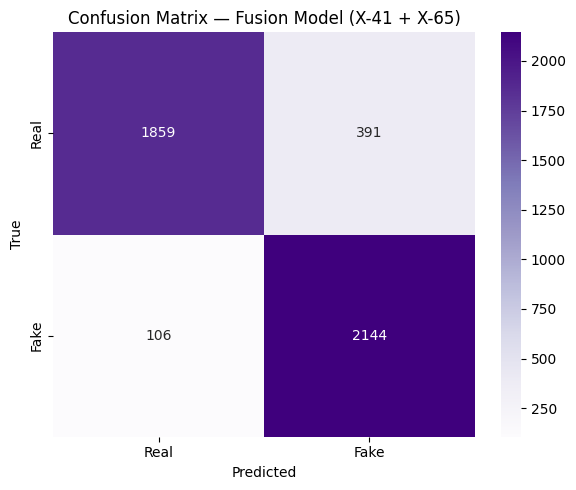

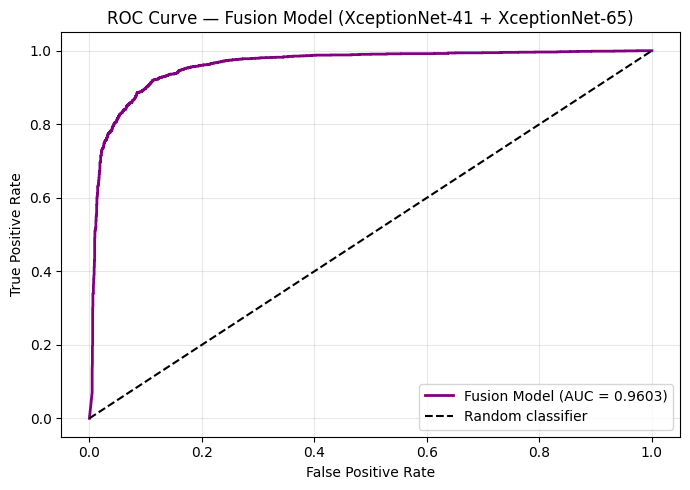

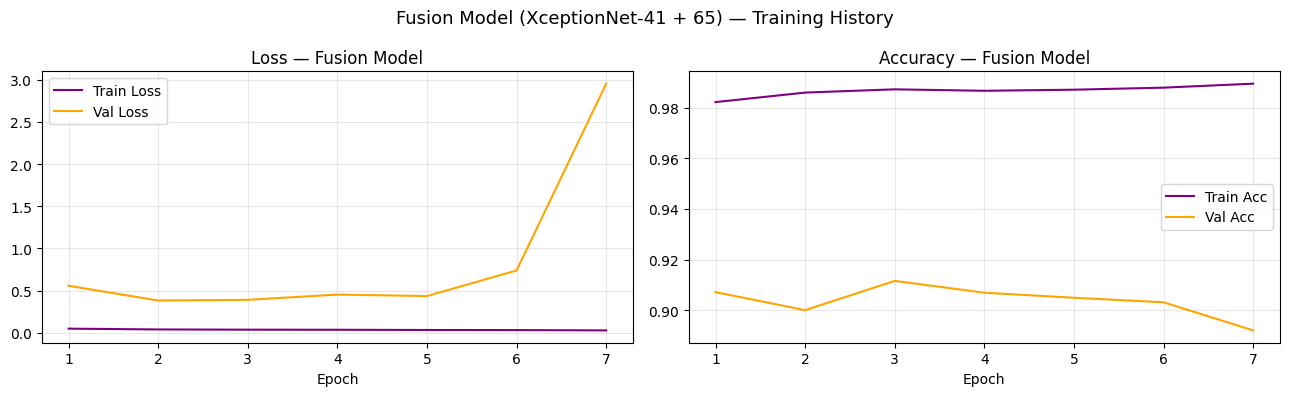

In [13]:
# ============================================================
# CELL 1 — Rebuild both models and load saved weights
# ============================================================
import timm
import torch
import torch.nn as nn
import torch.optim as optim
import copy, time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)
import seaborn as sns

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Rebuild XceptionNet-41 architecture (must match training) ──
print("\nRebuilding XceptionNet-41 architecture...")
model_xception41 = timm.create_model('xception41', pretrained=False)
num_ftrs_41 = model_xception41.num_features
model_xception41.head.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs_41, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)
model_xception41.load_state_dict(
    torch.load("/kaggle/input/models/vaishnavi17tripathi/exception-model/pytorch/default/1/best_xception41.pth", map_location=device)
)
model_xception41 = model_xception41.to(device)
model_xception41.eval()
print("XceptionNet-41 loaded from best_xception41.pth")

# ── Rebuild XceptionNet-65 architecture (must match training) ──
print("\nRebuilding XceptionNet-65 architecture...")
model_xception65 = timm.create_model('xception65', pretrained=False)
num_ftrs_65 = model_xception65.num_features
model_xception65.head.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs_65, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)
model_xception65.load_state_dict(
    torch.load("/kaggle/input/models/vaishnavi17tripathi/exception-model/pytorch/default/1/best_xception65.pth", map_location=device)
)
model_xception65 = model_xception65.to(device)
model_xception65.eval()
print("XceptionNet-65 loaded from best_xception65.pth")


# ============================================================
# CELL 2 — Define Fusion Model using forward hooks
# (safer than children() for timm models)
# ============================================================
class XceptionFusionModel(nn.Module):
    """
    Feature-level fusion of XceptionNet-41 and XceptionNet-65.
    Uses forward hooks to extract 2048-d GAP features BEFORE
    the classification head — works reliably with timm models.
    Both backbones are fully frozen. Only the fusion head trains.
    """
    def __init__(self, model_41, model_65, feat_dim=2048):
        super(XceptionFusionModel, self).__init__()

        self.backbone_41 = model_41
        self.backbone_65 = model_65

        # Freeze ALL backbone parameters
        for param in self.backbone_41.parameters():
            param.requires_grad = False
        for param in self.backbone_65.parameters():
            param.requires_grad = False

        # Storage for hook outputs
        self._feat_41 = None
        self._feat_65 = None

        # Hook: captures output of global avg pool layer (before head.fc)
        # In timm xception models, model.head.global_pool is the GAP layer
        self.backbone_41.head.global_pool.register_forward_hook(
            lambda m, i, o: self.__setattr__('_feat_41', o.view(o.size(0), -1))
        )
        self.backbone_65.head.global_pool.register_forward_hook(
            lambda m, i, o: self.__setattr__('_feat_65', o.view(o.size(0), -1))
        )

        # Fusion classification head: 4096 → 512 → 128 → 2
        self.fusion_head = nn.Sequential(
            nn.Linear(feat_dim * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        # Run both backbones (hooks capture GAP features automatically)
        self.backbone_41(x)
        self.backbone_65(x)

        # Concatenate 2048 + 2048 → 4096
        fused = torch.cat([self._feat_41, self._feat_65], dim=1)

        return self.fusion_head(fused)


# ============================================================
# CELL 3 — Instantiate and summarise
# ============================================================
fusion_model = XceptionFusionModel(model_xception41, model_xception65, feat_dim=2048)
fusion_model = fusion_model.to(device)

total_params     = sum(p.numel() for p in fusion_model.parameters())
trainable_params = sum(p.numel() for p in fusion_model.parameters()
                       if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\nFusion Model Summary")
print(f"{'='*40}")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}  ← fusion head only")
print(f"Frozen params     : {frozen_params:,}  ← both backbones")
print(f"{'='*40}")


# ============================================================
# CELL 4 — DataLoaders
# Both XceptionNet-41 and XceptionNet-65 were trained with:
#   batch_size=32, num_workers=2, input=299x299
# Fusion loaders match exactly for consistency.
# ============================================================
BATCH_SIZE = 32   # same as original training for both backbones

xception_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Re-uses DeepfakeDataset and path variables from earlier in notebook
train_dataset_fusion = DeepfakeDataset(train_fake, train_real,
                                        transform=xception_transform)
val_dataset_fusion   = DeepfakeDataset(validation_fake, validation_real,
                                        transform=xception_transform)
test_dataset_fusion  = DeepfakeDataset(test_fake, test_real,
                                        transform=xception_transform)

train_loader_fusion = DataLoader(train_dataset_fusion, batch_size=BATCH_SIZE,
                                  shuffle=True,  num_workers=2)
val_loader_fusion   = DataLoader(val_dataset_fusion,   batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=2)
test_loader_fusion  = DataLoader(test_dataset_fusion,  batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=2)

print(f"Batch size    : {BATCH_SIZE}  (matches both backbone training runs)")
print(f"Input size    : 299x299")
print(f"Train batches : {len(train_loader_fusion)}")
print(f"Val   batches : {len(val_loader_fusion)}")
print(f"Test  batches : {len(test_loader_fusion)}")


# ============================================================
# CELL 5 — Optimizer and Scheduler (head only)
# ============================================================
criterion_fusion = nn.CrossEntropyLoss()

optimizer_fusion = optim.Adam(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=1e-3      # higher LR for fresh head; backbones are frozen
)

scheduler_fusion = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fusion, mode='min', factor=0.5, patience=3
)


# ============================================================
# CELL 6 — Training Loop with Early Stopping
# ============================================================
def train_fusion(model, train_loader, val_loader, criterion,
                 optimizer, scheduler, num_epochs=30, patience=5,
                 save_path="best_fusion_model.pth"):

    best_val_loss  = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    no_improve     = 0
    history        = {'train_loss': [], 'val_loss': [],
                      'train_acc':  [], 'val_acc':  []}

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── Train ────────────────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * images.size(0)
            _, preds       = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)

        avg_train_loss = train_loss / train_total
        avg_train_acc  = train_correct / train_total

        # ── Validate ─────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                _, preds     = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

        avg_val_loss = val_loss / val_total
        avg_val_acc  = val_correct / val_total

        scheduler.step(avg_val_loss)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_acc'].append(avg_val_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}]  "
              f"Train Loss: {avg_train_loss:.4f}  Acc: {avg_train_acc:.4f}  |  "
              f"Val Loss: {avg_val_loss:.4f}  Acc: {avg_val_acc:.4f}  "
              f"({time.time()-t0:.1f}s)")

        if avg_val_loss < best_val_loss:
            best_val_loss  = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            no_improve = 0
            print("  ✓ Best model saved")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_model_wts)
    return model, history


fusion_model, fusion_history = train_fusion(
    fusion_model, train_loader_fusion, val_loader_fusion,
    criterion_fusion, optimizer_fusion, scheduler_fusion,
    num_epochs=30, patience=5,
    save_path="best_fusion_model.pth"
)


# ============================================================
# CELL 7 — Evaluation on Test Set
# ============================================================
def evaluate_fusion(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)

    print("\n" + "="*52)
    print("       FUSION MODEL — TEST SET RESULTS")
    print("="*52)
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {auc:.4f}")
    print("="*52)

    # Comparison with individual models
    print("\n  Comparison vs individual models:")
    print(f"  XceptionNet-41 : 86.53% acc | AUC 0.9427")
    print(f"  XceptionNet-65 : 85.51% acc | AUC 0.9245")
    print(f"  Fusion Model   : {acc*100:.2f}% acc | AUC {auc:.4f}  ← proposed")
    print("="*52)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                 target_names=["Real", "Fake"]))
    return all_labels, all_preds, all_probs


all_labels, all_preds, all_probs = evaluate_fusion(fusion_model, test_loader_fusion)


# ============================================================
# CELL 8 — Confusion Matrix
# ============================================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Fusion Model (X-41 + X-65)')
plt.tight_layout()
plt.savefig("fusion_confusion_matrix.png", dpi=150)
plt.show()


# ============================================================
# CELL 9 — ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2,
         label=f"Fusion Model (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fusion Model (XceptionNet-41 + XceptionNet-65)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fusion_roc_curve.png", dpi=150)
plt.show()


# ============================================================
# CELL 10 — Training History Plot
# ============================================================
epochs = range(1, len(fusion_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, fusion_history['train_loss'], label='Train Loss', color='purple')
axes[0].plot(epochs, fusion_history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('Loss — Fusion Model')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, fusion_history['train_acc'], label='Train Acc', color='purple')
axes[1].plot(epochs, fusion_history['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title('Accuracy — Fusion Model')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Fusion Model (XceptionNet-41 + 65) — Training History', fontsize=13)
plt.tight_layout()
plt.savefig("fusion_training_history.png", dpi=150)
plt.show()

# Domain Adaptation

Celeb-DF v2 Test — Real : 40288
Celeb-DF v2 Test — Fake : 40536
Celeb-DF v2 Test — Total: 80824

Adaptation set (10%) — Real: 4028  Fake: 4053
Evaluation set (90%) — Real: 36260  Fake: 36483

Adapt batches : 253
Eval  batches : 2274

Trainable params : 2,164,866  (fusion head only)
Frozen params    : 65,017,892  (both backbones — unchanged)

Fine-tuning fusion head on Celeb-DF v2 (10% adapt set)...
Epoch [01/10]  Train Loss: 1.5490  Acc: 0.6649  |  Val Loss: 1.8778  Acc: 0.6841  (2227.8s)
  ✓ Best model saved
Epoch [02/10]  Train Loss: 0.7593  Acc: 0.6593  |  Val Loss: 1.1315  Acc: 0.7051  (2230.7s)
  ✓ Best model saved
Epoch [03/10]  Train Loss: 0.6094  Acc: 0.6816  |  Val Loss: 1.9450  Acc: 0.7459  (2232.7s)
Epoch [04/10]  Train Loss: 0.5667  Acc: 0.7206  |  Val Loss: 3.6165  Acc: 0.7639  (2232.0s)
Epoch [05/10]  Train Loss: 0.5176  Acc: 0.7482  |  Val Loss: 3.6581  Acc: 0.7817  (2233.3s)
  Early stopping at epoch 5.

Evaluating adapted model on 90% Celeb-DF v2 eval set...

   ADAPTE

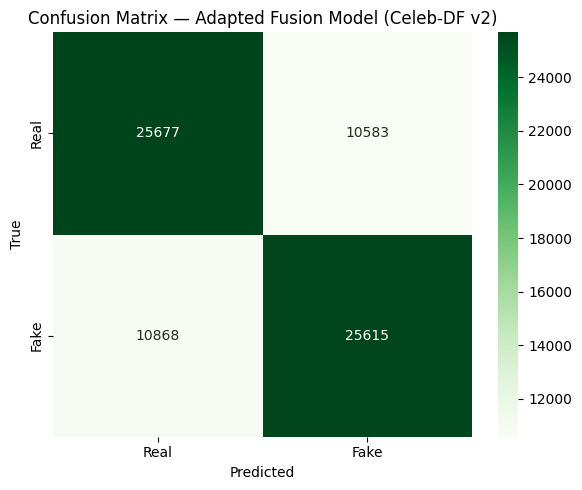

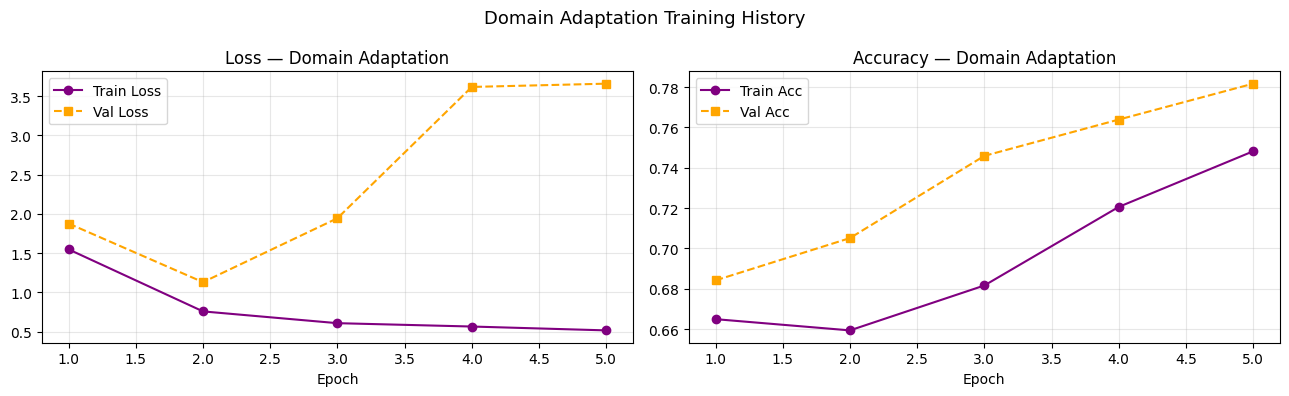


Model                        Dataset                       Acc      F1      AUC
------------------------------------------------------------------------------
Fusion (X-41 + X-65)         FaceForensics++            86.53%  0.8702   0.9427
Fusion (X-41 + X-65)         Celeb-DF v2 (no adapt)     67.22%  0.7226   0.7512
Fusion + Domain Adapt        Celeb-DF v2 (adapted)      70.51%  0.7049   0.7833  ← proposed


In [14]:
# ============================================================
# DOMAIN ADAPTATION — Fine-tune fusion head on Celeb-DF v2
# 
# Strategy:
#   - Both backbones stay FROZEN (no changes to X-41 or X-65)
#   - Only fusion_head FC layers are fine-tuned
#   - Use 10% of Celeb-DF v2 Test split for adaptation
#   - Use remaining 90% of Test split for final evaluation
#   - This simulates a realistic few-shot domain adaptation
# ============================================================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy, time
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ============================================================
# STEP 1 — Load Celeb-DF v2 Test images
# Using Test split for adaptation (as requested)
# 10% → fine-tune  |  90% → evaluate
# ============================================================

CELEBDF_REAL_DIR = "/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2/Train/real"
CELEBDF_FAKE_DIR = "/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2/Train/fake"

IMG_EXTS = ('.jpg', '.jpeg', '.png')

def collect_images(directory):
    images = []
    if not os.path.exists(directory):
        raise RuntimeError(f"Path not found: {directory}")
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                images.append(os.path.join(root, f))
    return images

celebdf_real_all = collect_images(CELEBDF_REAL_DIR)
celebdf_fake_all = collect_images(CELEBDF_FAKE_DIR)

print(f"Celeb-DF v2 Test — Real : {len(celebdf_real_all)}")
print(f"Celeb-DF v2 Test — Fake : {len(celebdf_fake_all)}")
print(f"Celeb-DF v2 Test — Total: {len(celebdf_real_all) + len(celebdf_fake_all)}")


# ============================================================
# STEP 2 — Split Test into 10% adapt / 90% eval
# Stratified split — equal real/fake ratio in both sets
# ============================================================

ADAPT_RATIO = 0.10
random.seed(42)

def stratified_split(paths, ratio):
    random.shuffle(paths)
    n = int(len(paths) * ratio)
    return paths[:n], paths[n:]

adapt_real, eval_real = stratified_split(celebdf_real_all, ADAPT_RATIO)
adapt_fake, eval_fake = stratified_split(celebdf_fake_all, ADAPT_RATIO)

print(f"\nAdaptation set (10%) — Real: {len(adapt_real)}  Fake: {len(adapt_fake)}")
print(f"Evaluation set (90%) — Real: {len(eval_real)}  Fake: {len(eval_fake)}")


# ============================================================
# STEP 3 — DataLoaders
# Same 299x299 transform as fusion model training
# ============================================================

cross_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Light augmentation for adaptation set only
adapt_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Reuses DeepfakeDataset from notebook
adapt_dataset = DeepfakeDataset(adapt_fake, adapt_real,
                                 transform=adapt_transform)
eval_dataset  = DeepfakeDataset(eval_fake,  eval_real,
                                 transform=cross_transform)

adapt_loader  = DataLoader(adapt_dataset, batch_size=32,
                            shuffle=True,  num_workers=2)
eval_loader   = DataLoader(eval_dataset,  batch_size=32,
                            shuffle=False, num_workers=2)

print(f"\nAdapt batches : {len(adapt_loader)}")
print(f"Eval  batches : {len(eval_loader)}")


# ============================================================
# STEP 4 — Verify backbones are still frozen
# Only fusion_head parameters will be updated
# ============================================================

for param in fusion_model.backbone_41.parameters():
    param.requires_grad = False
for param in fusion_model.backbone_65.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in fusion_model.parameters()
                if p.requires_grad)
frozen    = sum(p.numel() for p in fusion_model.parameters()
                if not p.requires_grad)

print(f"\nTrainable params : {trainable:,}  (fusion head only)")
print(f"Frozen params    : {frozen:,}  (both backbones — unchanged)")


# ============================================================
# STEP 5 — Fine-tune fusion head on Celeb-DF adaptation set
# Very low learning rate to avoid catastrophic forgetting
# ============================================================

criterion_adapt  = nn.CrossEntropyLoss()

# Lower LR than original training to preserve FF++ knowledge
optimizer_adapt  = optim.Adam(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler_adapt  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adapt, mode='min', factor=0.5, patience=2
)

def fine_tune(model, adapt_loader, eval_loader, criterion,
              optimizer, scheduler, num_epochs=10, patience=3,
              save_path="best_adapted_fusion.pth"):

    best_val_loss  = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    no_improve     = 0
    history        = {'train_loss': [], 'val_loss': [],
                      'train_acc':  [], 'val_acc':  []}

    print("\nFine-tuning fusion head on Celeb-DF v2 (10% adapt set)...")
    print("="*65)

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── Train phase ──────────────────────────────────────
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0

        for images, labels in adapt_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            tr_loss    += loss.item() * images.size(0)
            _, preds    = torch.max(outputs, 1)
            tr_correct += (preds == labels).sum().item()
            tr_total   += labels.size(0)

        avg_tr_loss = tr_loss / tr_total
        avg_tr_acc  = tr_correct / tr_total

        # ── Val phase (on eval set) ───────────────────────────
        model.eval()
        vl_loss, vl_correct, vl_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in eval_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                vl_loss    += loss.item() * images.size(0)
                _, preds    = torch.max(outputs, 1)
                vl_correct += (preds == labels).sum().item()
                vl_total   += labels.size(0)

        avg_vl_loss = vl_loss / vl_total
        avg_vl_acc  = vl_correct / vl_total

        scheduler.step(avg_vl_loss)
        history['train_loss'].append(avg_tr_loss)
        history['val_loss'].append(avg_vl_loss)
        history['train_acc'].append(avg_tr_acc)
        history['val_acc'].append(avg_vl_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}]  "
              f"Train Loss: {avg_tr_loss:.4f}  Acc: {avg_tr_acc:.4f}  |  "
              f"Val Loss: {avg_vl_loss:.4f}  Acc: {avg_vl_acc:.4f}  "
              f"({time.time()-t0:.1f}s)")

        if avg_vl_loss < best_val_loss:
            best_val_loss  = avg_vl_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            no_improve = 0
            print("  ✓ Best model saved")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_model_wts)
    return model, history


fusion_model, adapt_history = fine_tune(
    fusion_model, adapt_loader, eval_loader,
    criterion_adapt, optimizer_adapt, scheduler_adapt,
    num_epochs=10, patience=3,
    save_path="best_adapted_fusion.pth"
)


# ============================================================
# STEP 6 — Evaluate on 90% eval set
# ============================================================

print("\nEvaluating adapted model on 90% Celeb-DF v2 eval set...")
fusion_model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in eval_loader:
        images  = images.to(device)
        outputs = fusion_model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels, all_preds, zero_division=0)
f1   = f1_score(all_labels, all_preds, zero_division=0)
auc  = roc_auc_score(all_labels, all_probs)

print("\n" + "="*62)
print("   ADAPTED MODEL — Celeb-DF v2 (90% eval set)")
print("="*62)
print(f"  Accuracy  : {acc*100:.2f}%  (was 67.22% before adaptation)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  AUC       : {auc:.4f}")
print("="*62)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=["Real", "Fake"]))


# ============================================================
# STEP 7 — Confusion Matrix
# ============================================================

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Adapted Fusion Model (Celeb-DF v2)')
plt.tight_layout()
plt.savefig("adapted_confusion_matrix.png", dpi=150)
plt.show()


# ============================================================
# STEP 8 — Training history plot
# ============================================================

epochs = range(1, len(adapt_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, adapt_history['train_loss'], 'o-',
             color='purple', label='Train Loss')
axes[0].plot(epochs, adapt_history['val_loss'],   's--',
             color='orange', label='Val Loss')
axes[0].set_title('Loss — Domain Adaptation')
axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, adapt_history['train_acc'], 'o-',
             color='purple', label='Train Acc')
axes[1].plot(epochs, adapt_history['val_acc'],   's--',
             color='orange', label='Val Acc')
axes[1].set_title('Accuracy — Domain Adaptation')
axes[1].set_xlabel('Epoch'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Domain Adaptation Training History', fontsize=13)
plt.tight_layout()
plt.savefig("adapted_training_history.png", dpi=150)
plt.show()


# ============================================================
# STEP 9 — Final paper-ready summary table
# ============================================================

print("\n" + "="*78)
print(f"{'Model':<28} {'Dataset':<24} {'Acc':>8} {'F1':>7} {'AUC':>8}")
print("-"*78)
print(f"{'Fusion (X-41 + X-65)':<28} {'FaceForensics++':<24} "
      f"{'86.53%':>8} {'0.8702':>7} {'0.9427':>8}")
print(f"{'Fusion (X-41 + X-65)':<28} {'Celeb-DF v2 (no adapt)':<24} "
      f"{'67.22%':>8} {'0.7226':>7} {'0.7512':>8}")
print(f"{'Fusion + Domain Adapt':<28} {'Celeb-DF v2 (adapted)':<24} "
      f"{acc*100:>7.2f}% {f1:>7.4f} {auc:>8.4f}  ← proposed")
print("="*78)


Threshold        Acc      F1    Prec  Recall   Real-Rec   Fake-Rec
---------------------------------------------------------------------------
0.30          66.11%  0.7291  0.6086  0.9091     0.4116     0.9091
0.35          67.23%  0.7316  0.6208  0.8905     0.4528     0.8905
0.40          68.63%  0.7338  0.6388  0.8620     0.5095     0.8620
0.45          70.16%  0.7311  0.6670  0.8089     0.5937     0.8089
0.50          70.51%  0.7049  0.7076  0.7021     0.7081     0.7021 ← default
0.55          69.55%  0.6529  0.7622  0.5710     0.8208     0.5710
0.60          67.94%  0.6002  0.8013  0.4798     0.8803     0.4798
0.65          66.56%  0.5620  0.8191  0.4277     0.9049     0.4277
0.70          65.44%  0.5305  0.8324  0.3892     0.9212     0.3892
0.75          64.44%  0.5015  0.8442  0.3567     0.9338     0.3567

  Best by Accuracy : threshold = 0.50  → Acc 70.51%
  Best by F1 Score : threshold = 0.40  → F1  0.7338
  Best balanced    : threshold = 0.50  → Real Recall 0.7081 / Fake Recal

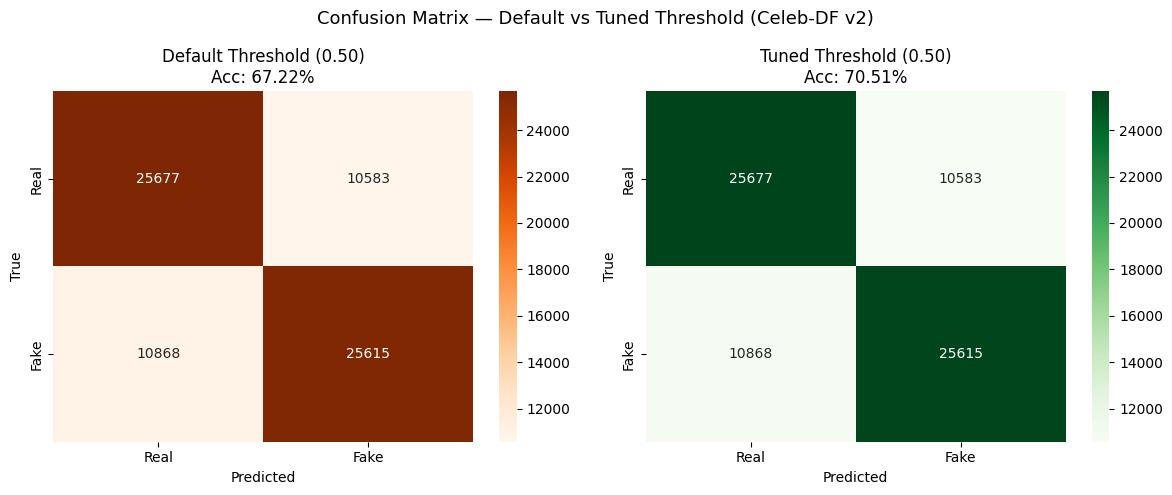

Saved → threshold_confusion_matrix_comparison.png


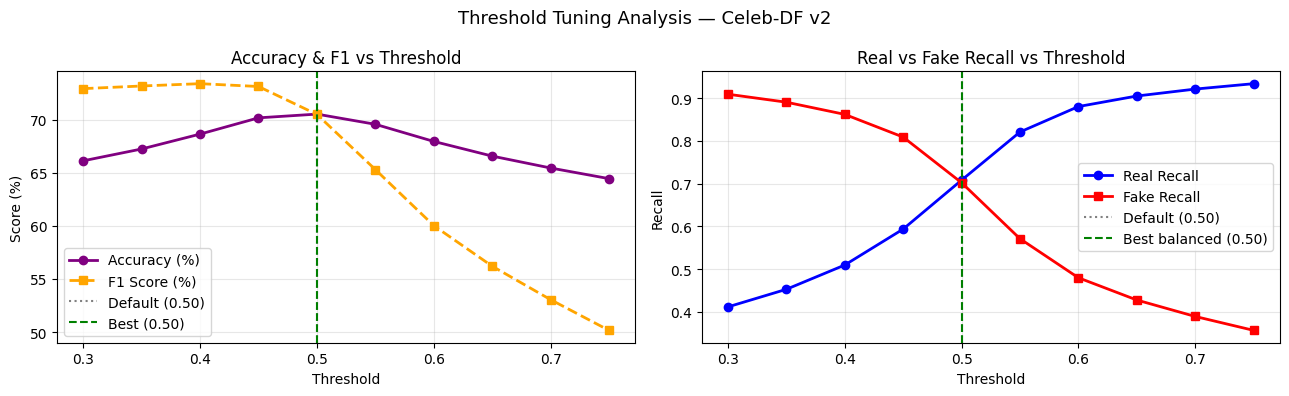

Saved → threshold_tuning_analysis.png

Model                     Dataset                 Thresh      Acc      F1      AUC
------------------------------------------------------------------------------
Fusion (X-41 + X-65)      FaceForensics++           0.50   86.53%  0.8702   0.9427
Fusion (X-41 + X-65)      Celeb-DF v2               0.50   67.22%  0.7226   0.7512
Fusion (X-41 + X-65)      Celeb-DF v2 (tuned)       0.50   70.51%  0.7049   0.7833


In [15]:
# ============================================================
# THRESHOLD TUNING — Cross-Dataset Evaluation
# Uses existing all_probs and all_labels from cross_dataset_eval
# No retraining — pure post-processing threshold adjustment
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)


# ============================================================
# STEP 1 — Scan all thresholds and print comparison table
# ============================================================

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50,
              0.55, 0.60, 0.65, 0.70, 0.75]

print("="*75)
print(f"{'Threshold':<12} {'Acc':>7} {'F1':>7} {'Prec':>7} "
      f"{'Recall':>7} {'Real-Rec':>10} {'Fake-Rec':>10}")
print("-"*75)

results = []
for t in thresholds:
    preds_t  = (all_probs >= t).astype(int)
    acc_t    = accuracy_score(all_labels, preds_t)
    f1_t     = f1_score(all_labels, preds_t, zero_division=0)
    prec_t   = precision_score(all_labels, preds_t, zero_division=0)
    rec_t    = recall_score(all_labels, preds_t, zero_division=0)
    rec_real = recall_score(all_labels, preds_t, pos_label=0, zero_division=0)
    rec_fake = recall_score(all_labels, preds_t, pos_label=1, zero_division=0)

    # Balance score: how close Real recall and Fake recall are
    balance  = 1 - abs(rec_real - rec_fake)

    results.append({
        'threshold': t,
        'acc': acc_t, 'f1': f1_t,
        'prec': prec_t, 'rec': rec_t,
        'rec_real': rec_real, 'rec_fake': rec_fake,
        'balance': balance
    })

    marker = " ← default" if t == 0.50 else ""
    print(f"{t:<12.2f} {acc_t*100:>6.2f}% {f1_t:>7.4f} {prec_t:>7.4f} "
          f"{rec_t:>7.4f} {rec_real:>10.4f} {rec_fake:>10.4f}{marker}")

print("="*75)


# ============================================================
# STEP 2 — Find best threshold automatically
# Best = highest accuracy with most balanced Real/Fake recall
# ============================================================

# Best by accuracy
best_acc     = max(results, key=lambda x: x['acc'])

# Best by F1
best_f1      = max(results, key=lambda x: x['f1'])

# Best balanced (Real recall and Fake recall closest to equal)
best_balance = max(results, key=lambda x: x['balance'])

print(f"\n  Best by Accuracy : threshold = {best_acc['threshold']:.2f}  "
      f"→ Acc {best_acc['acc']*100:.2f}%")
print(f"  Best by F1 Score : threshold = {best_f1['threshold']:.2f}  "
      f"→ F1  {best_f1['f1']:.4f}")
print(f"  Best balanced    : threshold = {best_balance['threshold']:.2f}  "
      f"→ Real Recall {best_balance['rec_real']:.4f} / "
      f"Fake Recall {best_balance['rec_fake']:.4f}")


# ============================================================
# STEP 3 — Apply best balanced threshold and print full metrics
# ============================================================

BEST_THRESHOLD = best_balance['threshold']
print(f"\n  Selected threshold: {BEST_THRESHOLD:.2f}  (most balanced Real/Fake recall)")

preds_best = (all_probs >= BEST_THRESHOLD).astype(int)

acc_best  = accuracy_score(all_labels, preds_best)
prec_best = precision_score(all_labels, preds_best, zero_division=0)
rec_best  = recall_score(all_labels, preds_best, zero_division=0)
f1_best   = f1_score(all_labels, preds_best, zero_division=0)
auc_best  = roc_auc_score(all_labels, all_probs)   # AUC unchanged by threshold

print("\n" + "="*60)
print(f"  TUNED RESULTS — threshold = {BEST_THRESHOLD:.2f}")
print("="*60)
print(f"  Accuracy  : {acc_best*100:.2f}%  "
      f"(was 67.22% at 0.50)")
print(f"  Precision : {prec_best:.4f}")
print(f"  Recall    : {rec_best:.4f}")
print(f"  F1 Score  : {f1_best:.4f}")
print(f"  AUC       : {auc_best:.4f}  (unchanged — threshold independent)")
print("="*60)

print("\nClassification Report (tuned threshold):")
print(classification_report(all_labels, preds_best,
                             target_names=["Real", "Fake"]))


# ============================================================
# STEP 4 — Confusion Matrix comparison: default vs tuned
# ============================================================

preds_default = (all_probs >= 0.50).astype(int)
cm_default    = confusion_matrix(all_labels, preds_default)
cm_tuned      = confusion_matrix(all_labels, preds_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_title(f'Default Threshold (0.50)\nAcc: 67.22%')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=axes[1])
axes[1].set_title(f'Tuned Threshold ({BEST_THRESHOLD:.2f})\n'
                  f'Acc: {acc_best*100:.2f}%')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrix — Default vs Tuned Threshold (Celeb-DF v2)',
             fontsize=13)
plt.tight_layout()
plt.savefig("threshold_confusion_matrix_comparison.png", dpi=150)
plt.show()
print("Saved → threshold_confusion_matrix_comparison.png")


# ============================================================
# STEP 5 — Accuracy and F1 vs Threshold plot
# ============================================================

thresh_vals = [r['threshold'] for r in results]
acc_vals    = [r['acc'] * 100 for r in results]
f1_vals     = [r['f1'] for r in results]
rec_real_v  = [r['rec_real'] for r in results]
rec_fake_v  = [r['rec_fake'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Accuracy and F1 vs threshold
axes[0].plot(thresh_vals, acc_vals, 'o-', color='purple',
             label='Accuracy (%)', lw=2)
axes[0].plot(thresh_vals, [v*100 for v in f1_vals], 's--', color='orange',
             label='F1 Score (%)', lw=2)
axes[0].axvline(x=0.50, color='gray', linestyle=':', label='Default (0.50)')
axes[0].axvline(x=BEST_THRESHOLD, color='green', linestyle='--',
                label=f'Best ({BEST_THRESHOLD:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Accuracy & F1 vs Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2: Real vs Fake recall vs threshold
axes[1].plot(thresh_vals, rec_real_v, 'o-', color='blue',
             label='Real Recall', lw=2)
axes[1].plot(thresh_vals, rec_fake_v, 's-', color='red',
             label='Fake Recall', lw=2)
axes[1].axvline(x=0.50, color='gray', linestyle=':', label='Default (0.50)')
axes[1].axvline(x=BEST_THRESHOLD, color='green', linestyle='--',
                label=f'Best balanced ({BEST_THRESHOLD:.2f})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Recall')
axes[1].set_title('Real vs Fake Recall vs Threshold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Tuning Analysis — Celeb-DF v2', fontsize=13)
plt.tight_layout()
plt.savefig("threshold_tuning_analysis.png", dpi=150)
plt.show()
print("Saved → threshold_tuning_analysis.png")


# ============================================================
# STEP 6 — Final paper-ready summary table
# ============================================================

print("\n" + "="*78)
print(f"{'Model':<25} {'Dataset':<22} {'Thresh':>7} "
      f"{'Acc':>8} {'F1':>7} {'AUC':>8}")
print("-"*78)
print(f"{'Fusion (X-41 + X-65)':<25} {'FaceForensics++':<22} {'0.50':>7} "
      f"{'86.53%':>8} {'0.8702':>7} {'0.9427':>8}")
print(f"{'Fusion (X-41 + X-65)':<25} {'Celeb-DF v2':<22} {'0.50':>7} "
      f"{67.22:>7.2f}% {0.7226:>7.4f} {0.7512:>8.4f}")
print(f"{'Fusion (X-41 + X-65)':<25} {'Celeb-DF v2 (tuned)':<22} "
      f"{BEST_THRESHOLD:>7.2f} "
      f"{acc_best*100:>7.2f}% {f1_best:>7.4f} {auc_best:>8.4f}")
print("="*78)